<a href="https://colab.research.google.com/github/GroupQ-Assignment-DataScience/GroupQ_Assignment_RMD/blob/main/GroupQ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
# Import Required Libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [23]:
import pandas as pd
df = pd.read_csv('/content/dataset_C_training.csv')

In [24]:
df.head()

,respondent_id,covid_concern,covid_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,employment_status,census_msa,household_adults,household_children,doctor_recc_covid,opinion_covid_vacc_effective,opinion_covid_risk,opinion_covid_sick_from_vacc,employment_sector,covid_vaccine
0,1,3.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,Employed,"MSA, Principle City",3.0,2.0,0,4,4,2.0,construction,0
1,2,2.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Employed,Non-MSA,0.0,0.0,0,5,2,1.0,education,1
2,3,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Employed,"MSA, Not Principle City",0.0,0.0,0,2,2,5.0,wholesale,0
3,4,2.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Not in Labor Force,"MSA, Not Principle City",1.0,0.0,1,3,3,2.0,NaN,1
4,5,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,Employed,"MSA, Not Principle City",0.0,0.0,0,3,2,2.0,wholesale,0


In [25]:
# Basic Dataset Information
print("Shape of Dataset:", df.shape)

df.info()

Shape of Dataset: (4756, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4756 entries, 0 to 4755
Data columns (total 31 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   respondent_id                 4756 non-null   int64  
 1   covid_concern                 4744 non-null   float64
 2   covid_knowledge               4729 non-null   float64
 3   behavioral_antiviral_meds     4742 non-null   float64
 4   behavioral_avoidance          4729 non-null   float64
 5   behavioral_face_mask          4754 non-null   float64
 6   behavioral_wash_hands         4747 non-null   float64
 7   behavioral_large_gatherings   4746 non-null   float64
 8   behavioral_outside_home       4742 non-null   float64
 9   behavioral_touch_face         4735 non-null   float64
 10  chronic_med_condition         4587 non-null   float64
 11  child_under_6_months          4621 non-null   float64
 12  health_worker                 462

In [26]:
# ==========================================
# STEP 4: Check Missing Values
# ==========================================

missing_values = df.isnull().sum()

# Show columns with missing values
missing_values[missing_values > 0].sort_values(ascending=False)

,0
employment_sector,2330
health_insurance,1908
income_poverty,748
rent_or_own,329
employment_status,238
marital_status,231
education,228
chronic_med_condition,169
child_under_6_months,135
health_worker,132


In [27]:
# ==========================================
# STEP 5: Calculate Missing Value Percentage
# ==========================================

missing_percent = (df.isnull().sum() / len(df)) * 100

missing_report = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage': missing_percent
})

missing_report[missing_report['Missing Values'] > 0]\
.sort_values(by='Percentage', ascending=False)

,Missing Values,Percentage
employment_sector,2330,48.990749
health_insurance,1908,40.117746
income_poverty,748,15.727502
rent_or_own,329,6.917578
employment_status,238,5.004205
marital_status,231,4.857023
education,228,4.793944
chronic_med_condition,169,3.553406
child_under_6_months,135,2.838520
health_worker,132,2.775442


In [28]:
# Separate categorical and numerical columns

categorical_columns = df.select_dtypes(include='object').columns
numerical_columns = df.select_dtypes(exclude='object').columns

# Fill categorical missing values
for col in categorical_columns:
    df[col] = df[col].fillna("Unknown")

# Fill numerical missing values
for col in numerical_columns:
    df[col] = df[col].fillna(df[col].median())

In [29]:
# Check remaining missing values

print("Remaining Missing Values:")
print(df.isnull().sum().sum())

Remaining Missing Values:
0


In [30]:
# Convert categorical variables into numerical format

label_encoder = LabelEncoder()

for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col])

df.head()

,respondent_id,covid_concern,covid_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,employment_status,census_msa,household_adults,household_children,doctor_recc_covid,opinion_covid_vacc_effective,opinion_covid_risk,opinion_covid_sick_from_vacc,employment_sector,covid_vaccine
0,1,3.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,0,1,3.0,2.0,0,4,4,2.0,3,0
1,2,2.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,0,2,0.0,0.0,0,5,2,1.0,4,1
2,3,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0.0,0.0,0,2,2,5.0,21,0
3,4,2.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,1,0,1.0,0.0,1,3,3,2.0,0,1
4,5,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0.0,0.0,0,3,2,2.0,21,0


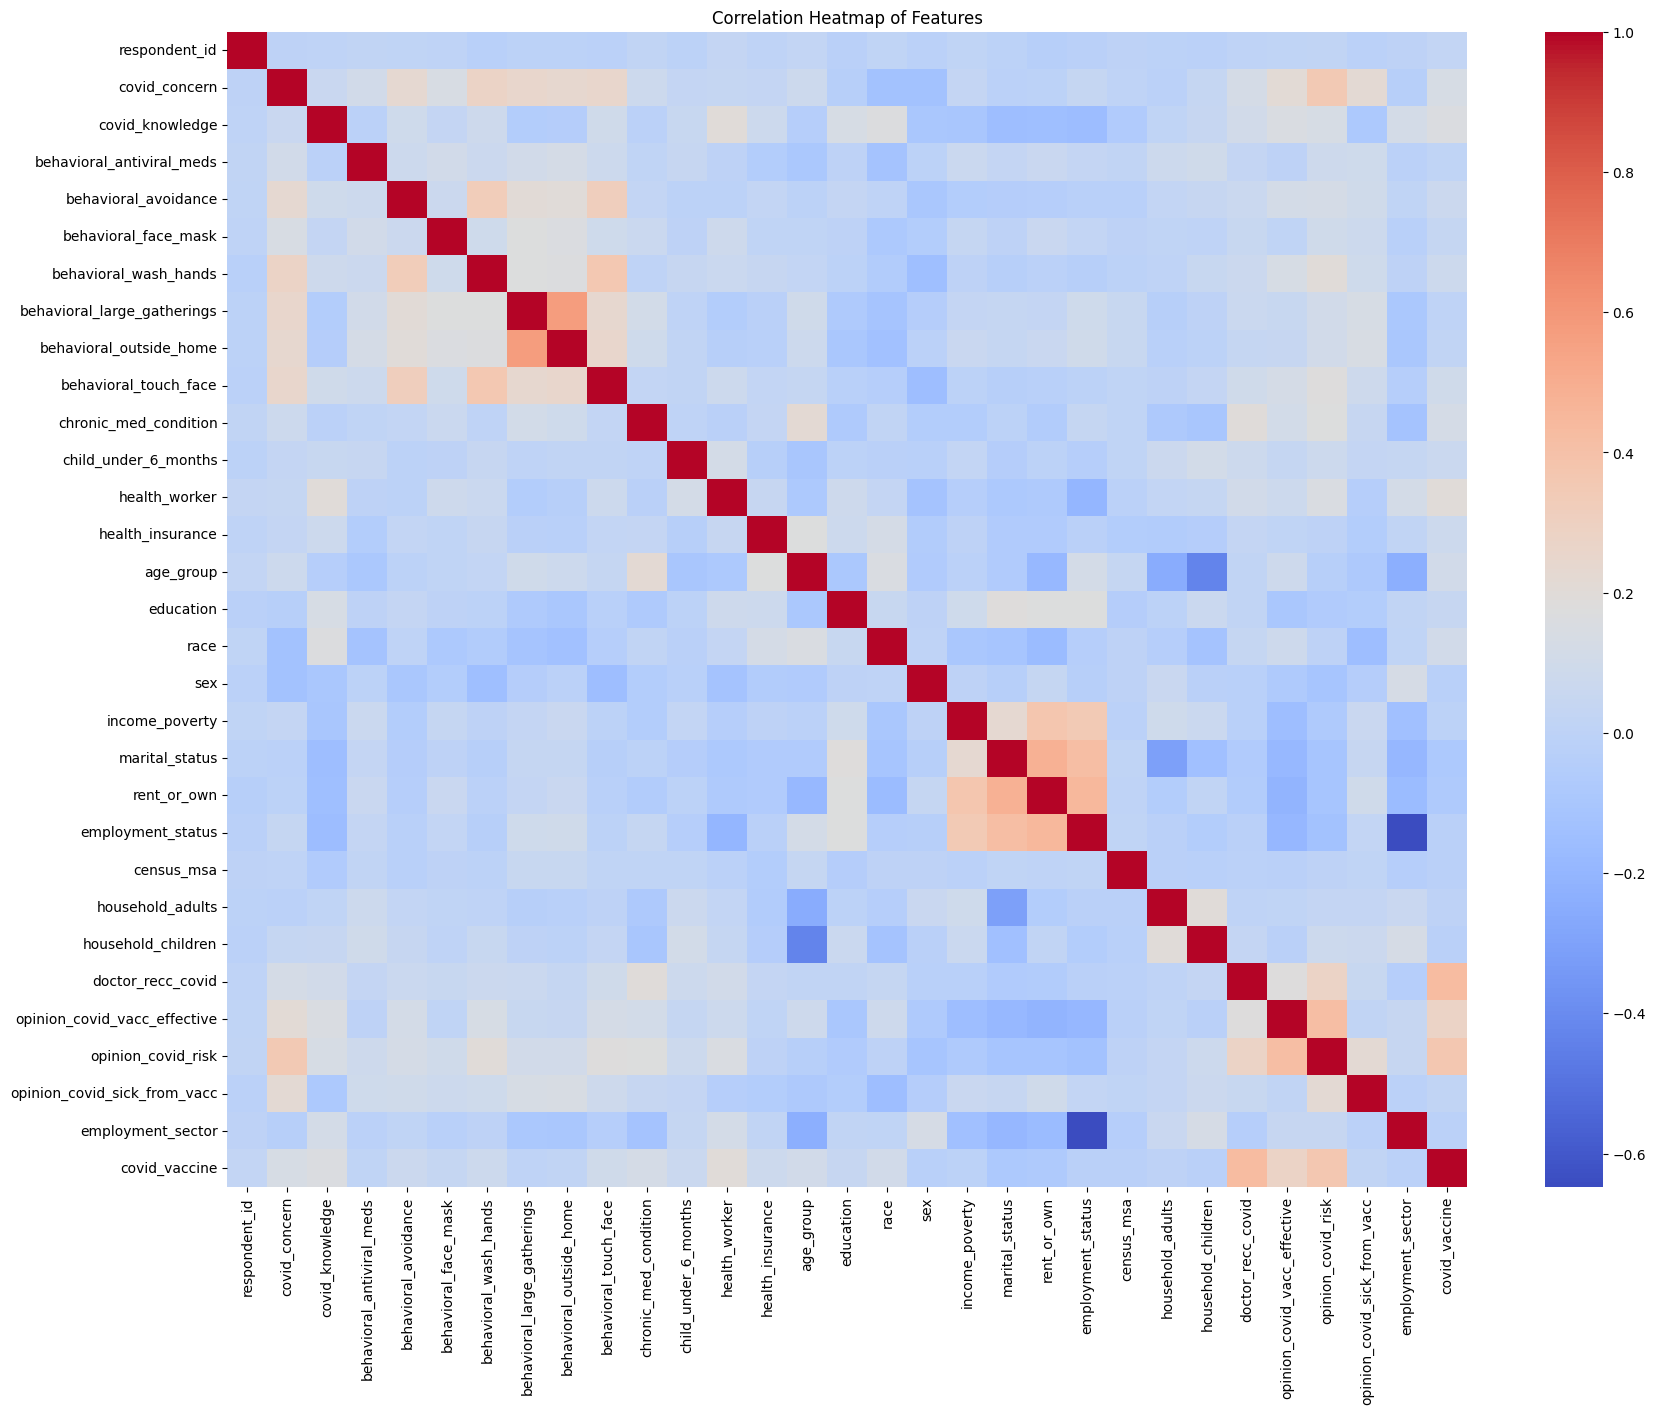

In [31]:
plt.figure(figsize=(20, 15))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap of Features')
plt.show()

In [32]:
# Create feature matrix and target variable

X = df.drop("covid_vaccine", axis=1)
y = df["covid_vaccine"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (4756, 30)
Target Shape: (4756,)


In [33]:
# Split into training and testing datasets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (3804, 30)
Testing Set: (952, 30)


In [34]:
# Install H20AutoML (only need to do this once)
!pip install h2o

# Import packages
import h2o
from h2o.automl import H2OAutoML

# Start the H2O cluster (locally)
h2o.init()

Checking whether there is an H2O instance running at http://localhost:54321. connected.


H2O_cluster_uptime:,41 mins 00 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.11
H2O_cluster_version_age:,"14 days, 1 hour and 17 minutes"
H2O_cluster_name:,H2O_from_python_unknownUser_o1ccaf
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.135 Gb
H2O_cluster_total_cores:,2
H2O_cluster_allowed_cores:,2
H2O_cluster_status:,"locked, healthy"


In [35]:
# Define the target variable (i.e. "response") and features (i.e. "predictors") for H20AutoML
response = 'covid_vaccine'
predictors = list(df.drop('covid_vaccine', axis=1).columns)

# Convert from a pandas dataframe to an h20 frame
hf = h2o.H2OFrame(df)

# Convert target column to categorical, as this is a binary classification problem
hf['covid_vaccine'] = hf['covid_vaccine'].asfactor()

# Split the data into training and testing sets using the H20 split_frame() method
train, test = hf.split_frame(seed=1, ratios=[0.75])

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%


In [36]:
# Set-up and train the models
aml = H2OAutoML(max_runtime_secs=120, seed=1, include_algos=["GLM", "DRF", "XGBoost"])
aml.train(x=predictors, y=response, training_frame=train)

# Turn off default printed output
h2o.display.toggle_user_tips()

AutoML progress: |███████████████████████████████████████████████████████████████| (done) 100%


In [37]:
# Show leaderboard & performance information
aml.explain(test, include_explanations=["leaderboard"]);

# Leaderboard

> Leaderboard shows models with their metrics. When provided with H2OAutoML object, the leaderboard shows 5-fold cross-validated metrics by default (depending on the H2OAutoML settings), otherwise it shows metrics computed on the frame. At most 20 models are shown by default.

model_id,auc,logloss,aucpr,mean_per_class_error,rmse,mse,training_time_ms,predict_time_per_row_ms,algo
XGBoost_3_AutoML_2_20260605_105925,0.822249,0.484559,0.707125,0.245293,0.395901,0.156737,414,0.009769,XGBoost
GLM_1_AutoML_2_20260605_105925,0.819916,0.482103,0.730182,0.242861,0.392933,0.154396,825,0.008625,GLM
XGBoost_grid_1_AutoML_2_20260605_105925_model_3,0.814311,0.497858,0.696113,0.260484,0.399424,0.15954,1573,0.011793,XGBoost
XGBoost_grid_1_AutoML_2_20260605_105925_model_5,0.813842,0.49666,0.695346,0.250935,0.399096,0.159277,692,0.00919,XGBoost
XGBoost_1_AutoML_2_20260605_105925,0.813556,0.49264,0.712306,0.259314,0.3988,0.159042,8882,0.009706,XGBoost
XGBoost_grid_1_AutoML_2_20260605_105925_model_4,0.812788,0.501536,0.697195,0.263623,0.40053,0.160424,557,0.025463,XGBoost
XGBoost_grid_1_AutoML_2_20260605_105925_model_2,0.812078,0.498766,0.694216,0.255064,0.401376,0.161102,570,0.010865,XGBoost
XRT_1_AutoML_2_20260605_105925,0.811881,0.502753,0.710842,0.25854,0.404685,0.16377,3245,0.041334,DRF
XGBoost_grid_1_AutoML_2_20260605_105925_model_6,0.806671,0.510356,0.683299,0.257229,0.406257,0.165045,464,0.009412,XGBoost
XGBoost_grid_1_AutoML_2_20260605_105925_model_1,0.805901,0.510283,0.679239,0.260156,0.407212,0.165822,3588,0.020957,XGBoost


# Variable Importance Heatmap

> Variable importance heatmap shows variable importance across multiple models. Some models in H2O return variable importance for one-hot (binary indicator) encoded versions of categorical columns (e.g. Deep Learning, XGBoost). In order for the variable importance of categorical columns to be compared across all model types we compute a summarization of the the variable importance across all one-hot encoded features and return a single variable importance for the original categorical feature. By default, the models and variables are ordered by their similarity.

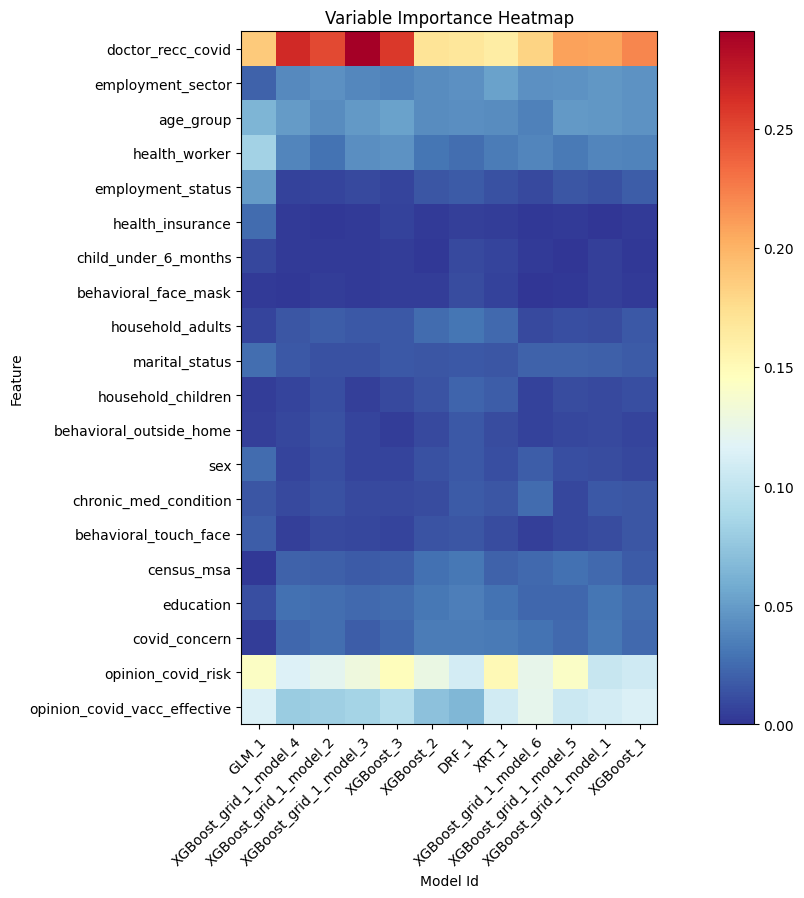

# Partial Dependence Plots

> Partial dependence plot (PDP) gives a graphical depiction of the marginal effect of a variable on the response. The effect of a variable is measured in change in the mean response. PDP assumes independence between the feature for which is the PDP computed and the rest.

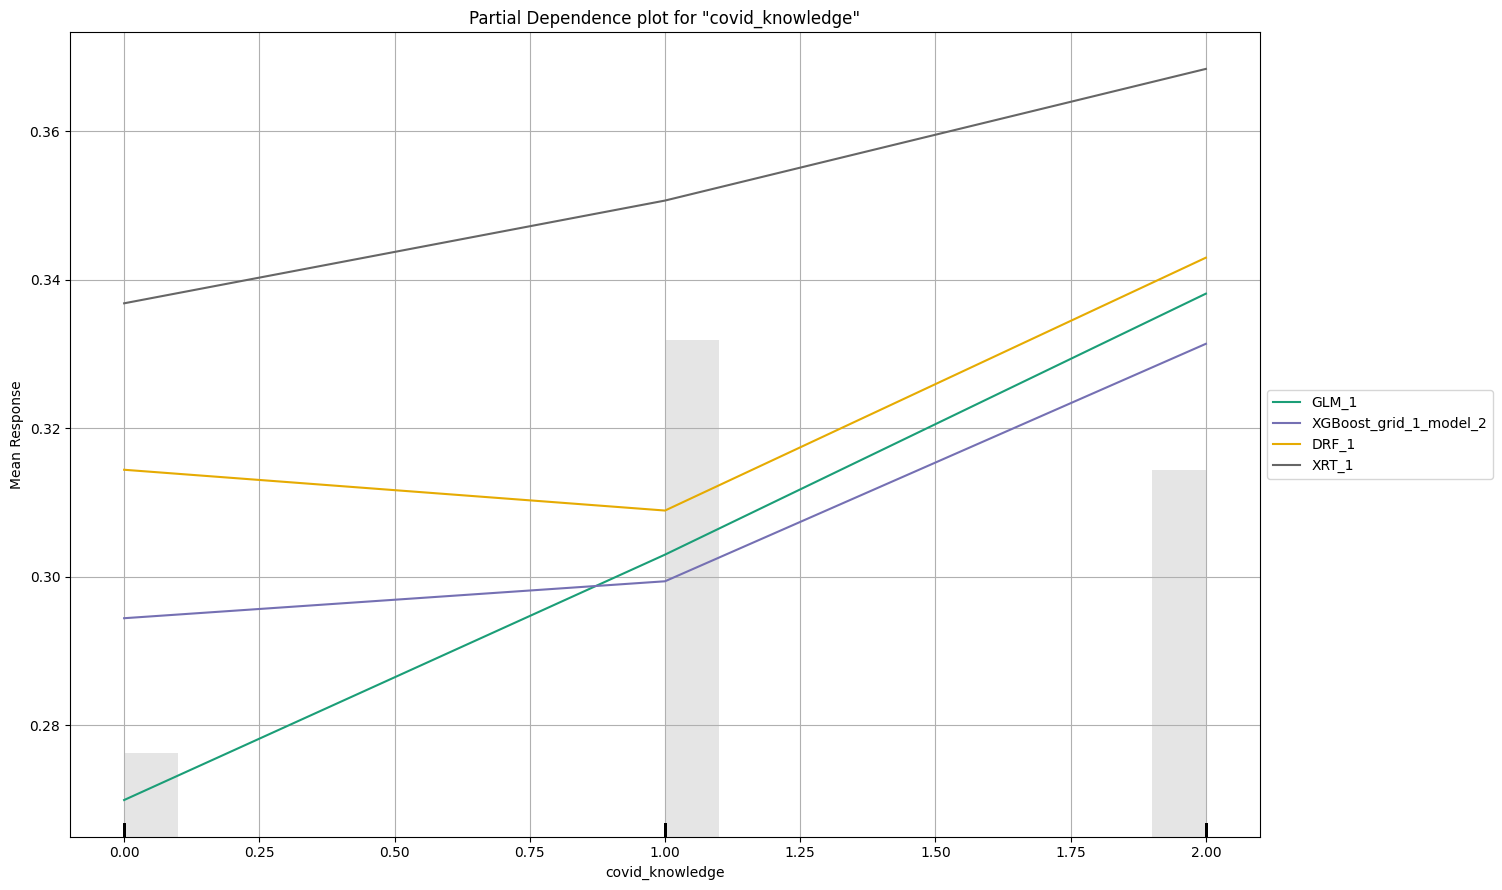

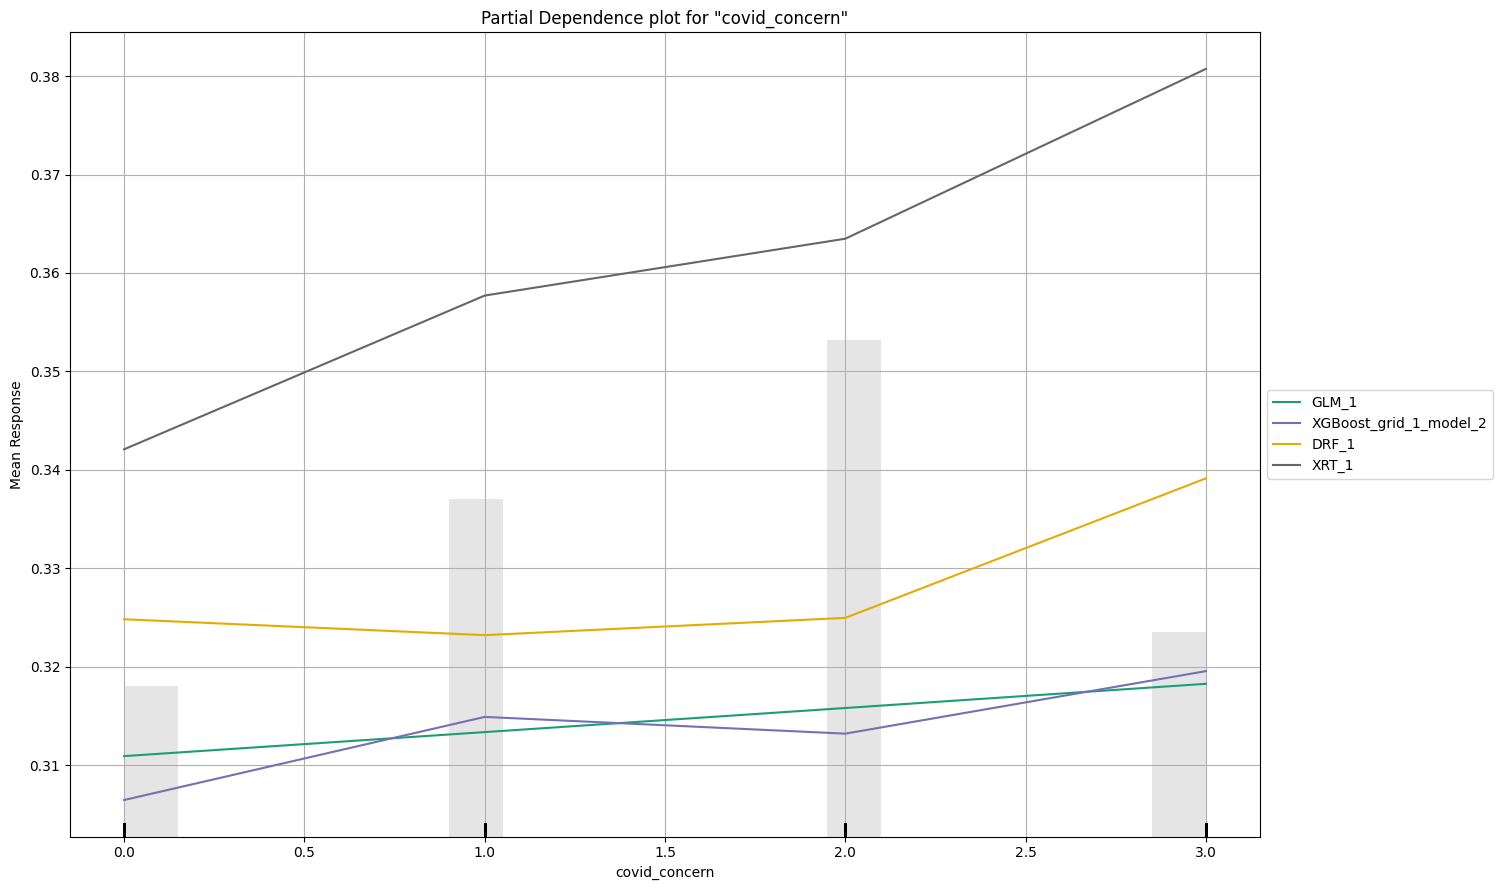

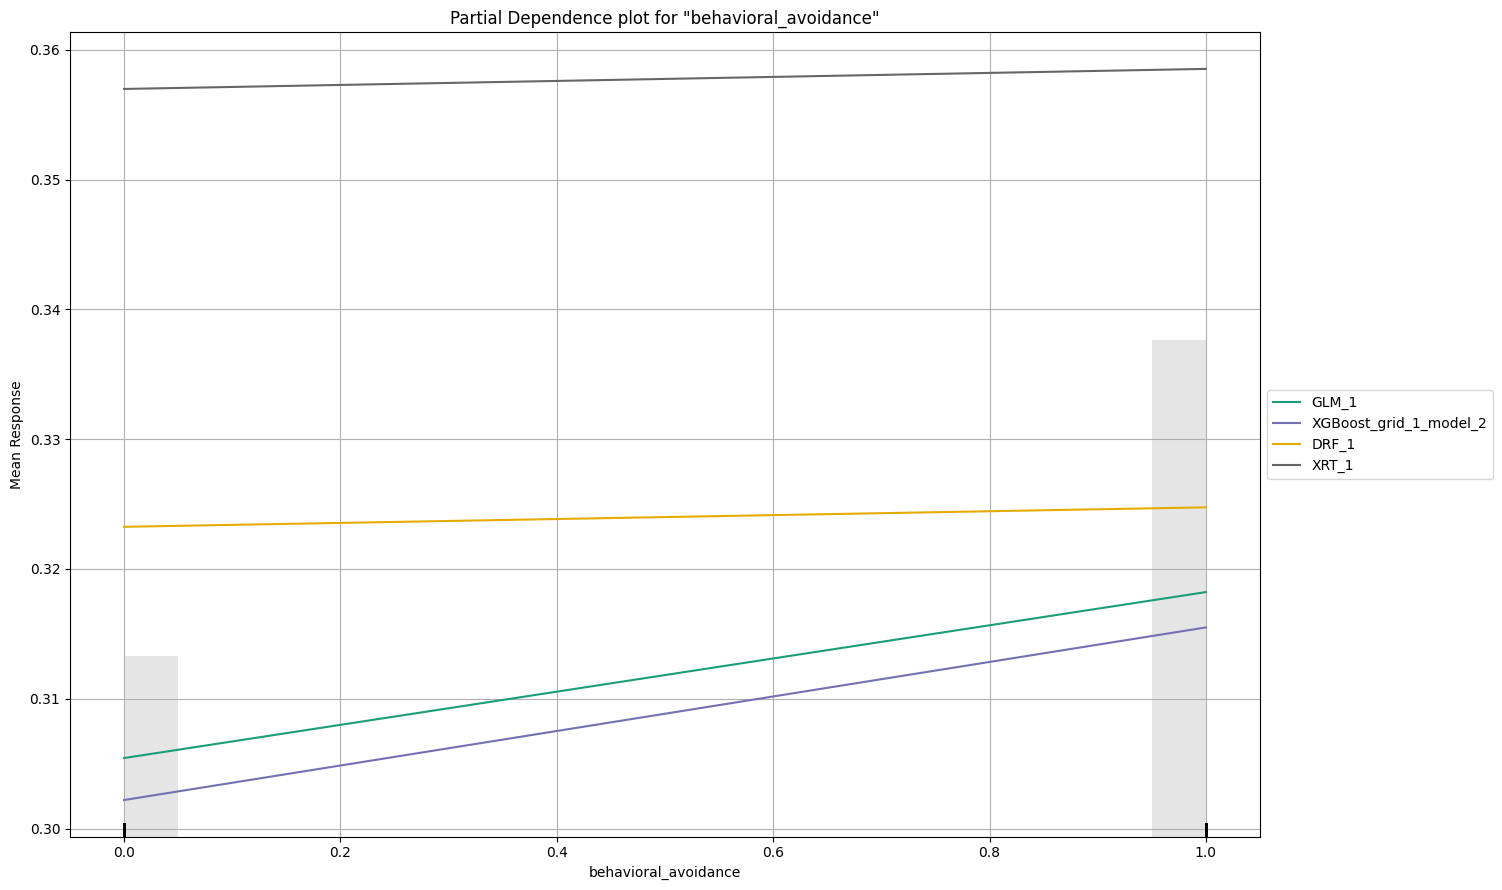

In [38]:
# Plot XAI information
aml.explain(test, include_explanations=["varimp_heatmap", "pdp"], \
            columns = ["covid_knowledge", "covid_concern", "behavioral_avoidance"]);

The `aml.leader` attribute returns the best model found by H2OAutoML. We can then use this model to make predictions on our test set and evaluate its performance.

In [39]:
best_model = aml.leader
predictions = best_model.predict(test)

# Display predictions (first 5 rows)
print("Predictions:")
predictions.head()

glm prediction progress: |███████████████████████████████████████████████████████| (done) 100%
Predictions:


predict,p0,p1
0,0.919646,0.0803542
0,0.762165,0.237835
0,0.907616,0.0923841
0,0.857999,0.142001
0,0.926802,0.073198
0,0.861965,0.138035
1,0.397016,0.602984
0,0.657949,0.342051
0,0.93457,0.0654299
0,0.85589,0.14411


In [40]:
print("Model performance on test set:")
performance = best_model.model_performance(test)
print(performance)

Model performance on test set:
ModelMetricsBinomialGLM: glm
** Reported on test data. **

MSE: 0.15439614730837398
RMSE: 0.3929327516361724
LogLoss: 0.48210312960859975
AUC: 0.8199163978460076
AUCPR: 0.7301818271007682
Gini: 0.6398327956920151
Null degrees of freedom: 1179
Residual degrees of freedom: 1149
Null deviance: 1509.6126773117362
Residual deviance: 1137.7633858762956
AIC: 1199.7633858762956

Confusion Matrix (Act/Pred) for max f1 @ threshold = 0.2657194530003334
       0    1    Error    Rate
-----  ---  ---  -------  --------------
0      579  203  0.2596   (203.0/782.0)
1      90   308  0.2261   (90.0/398.0)
Total  669  511  0.2483   (293.0/1180.0)

Maximum Metrics: Maximum metrics at their respective thresholds
metric                       threshold    value     idx
---------------------------  -----------  --------  -----
max f1                       0.265719     0.677668  236
max f2                       0.200891     0.757238  274
max f0point5                 0.436315   

To get a clearer view of the classification metrics for the best model, we can inspect specific metrics like AUC, F1-score, and Confusion Matrix.

In [42]:
print(f"AUC: {performance.auc()}")
print(f"F1 Score: {performance.F1()}")
print("Confusion Matrix:")
print(performance.confusion_matrix())

AUC: 0.8199163978460076
F1 Score: [[0.2657194530003334, 0.6776677667766776]]
Confusion Matrix:
Confusion Matrix (Act/Pred) for max f1 @ threshold = 0.2657194530003334
       0    1    Error    Rate
-----  ---  ---  -------  --------------
0      579  203  0.2596   (203.0/782.0)
1      90   308  0.2261   (90.0/398.0)
Total  669  511  0.2483   (293.0/1180.0)


Edward

In [ ]:
dfjgbfsjgb

In [ ]:
shdfbuadsb

In [ ]:
diufhdfuiph

In [ ]:
dpuifghsdiuh